# EDA

### Configuração

In [19]:
# CRISP-DM: preparação de dados fase 3 (ETL - Transform & Load)
import os
import pandas as pd
import numpy as np  

# CRISP-DM: análise exploratória de dados fase 3
import matplotlib
# Configura o backend do matplotlib (se não houver DISPLAY gráfico, usa Agg)
if not os.environ.get('DISPLAY'):
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder # converter coluna string/categórica em numérica

# Integração com a camada Bronze (Extração)
from extraction import extrair_base


CAMINHO_SILVER = "./data/dfimoveis_silver.csv"

### Extrair base silver para analise

In [20]:
dados_silver = extrair_base(CAMINHO_SILVER)


[EXTRAÇÃO] Dados carregados com sucesso de './data/dfimoveis_silver.csv': 8444 registros e 8 colunas.


### Analise dos dados silver

In [21]:
print(dados_silver.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8191 entries, 0 to 8190
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   preco_venda       8191 non-null   float64
 1   tipo_imovel       8191 non-null   int64  
 2   bairro_quadra     8191 non-null   int64  
 3   area_util         8191 non-null   float64
 4   quartos           8191 non-null   float64
 5   suites            8191 non-null   int64  
 6   vagas             8191 non-null   int64  
 7   valor_condominio  8191 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 512.1 KB


### Histograma dos campos númericos

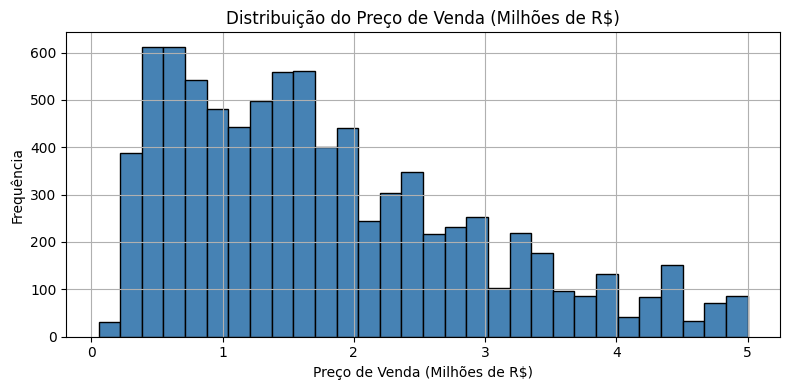

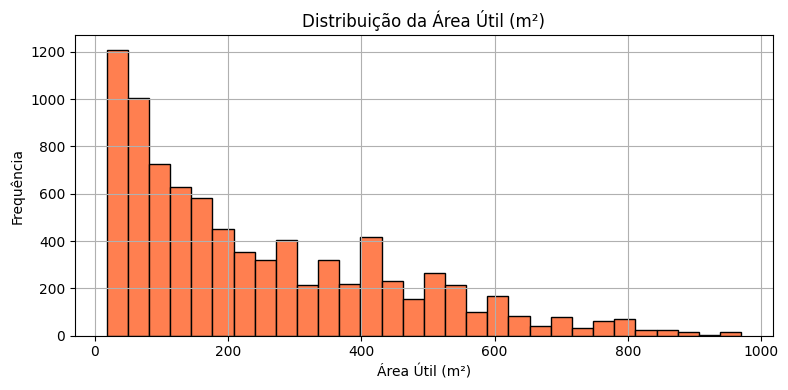

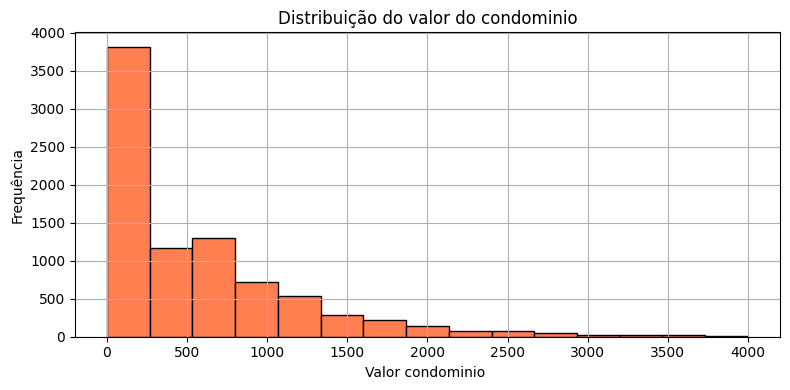

In [22]:
# Histograma do preço do imóvel
plt.figure(figsize=(8, 4))
(dados_silver['preco_venda'] / 1e6).hist(bins=30, edgecolor='black', color='steelblue')
plt.title("Distribuição do Preço de Venda (Milhões de R$)")
plt.xlabel("Preço de Venda (Milhões de R$)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

# Histograma da área útil
plt.figure(figsize=(8, 4))
dados_silver['area_util'].hist(bins=30, edgecolor='black', color='coral')
plt.title("Distribuição da Área Útil (m²)")
plt.xlabel("Área Útil (m²)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

# Histograma do valor do condominio
plt.figure(figsize=(8, 4))
dados_silver['valor_condominio'].hist(bins=15, edgecolor='black', color='coral')
plt.title("Distribuição do valor do condominio")
plt.xlabel("Valor condominio ")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

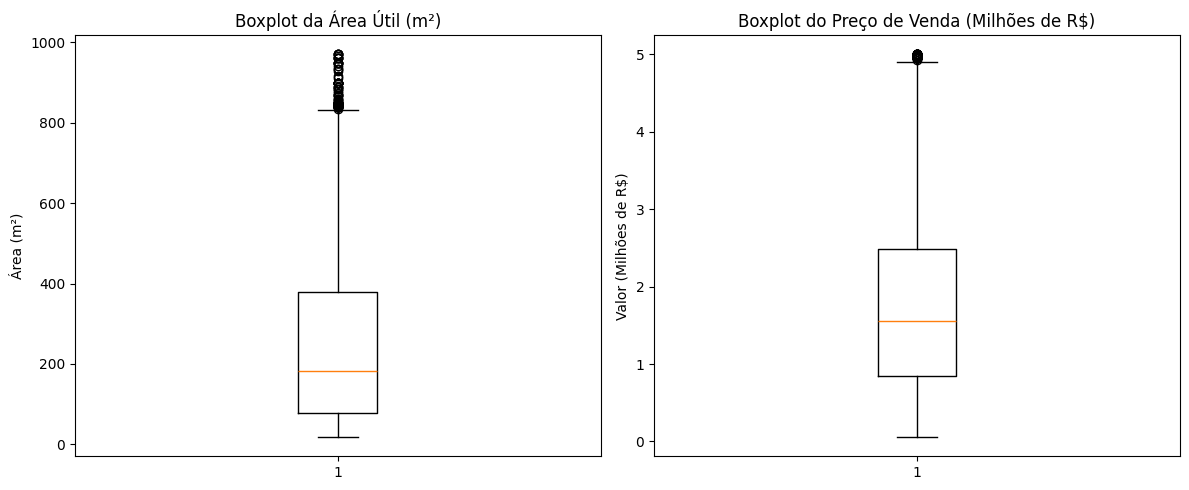

In [23]:
def gerarBoxplot(dados):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Boxplot da Área Útil
    axes[0].boxplot(dados['area_util'])
    axes[0].set_title("Boxplot da Área Útil (m²)")
    axes[0].set_ylabel("Área (m²)")

    # Boxplot do Preço de Venda em Milhões de R$
    axes[1].boxplot(dados['preco_venda'] / 1e6)
    axes[1].set_title("Boxplot do Preço de Venda (Milhões de R$)")
    axes[1].set_ylabel("Valor (Milhões de R$)")

    plt.tight_layout()
    plt.show()

gerarBoxplot(dados_silver)

--- Resumo Estatístico ---
count    8444.000000
mean      530.016106
std       652.915866
min         0.000000
25%         0.000000
50%       384.000000
75%       800.000000
max      4000.000000
Name: valor_condominio, dtype: float64




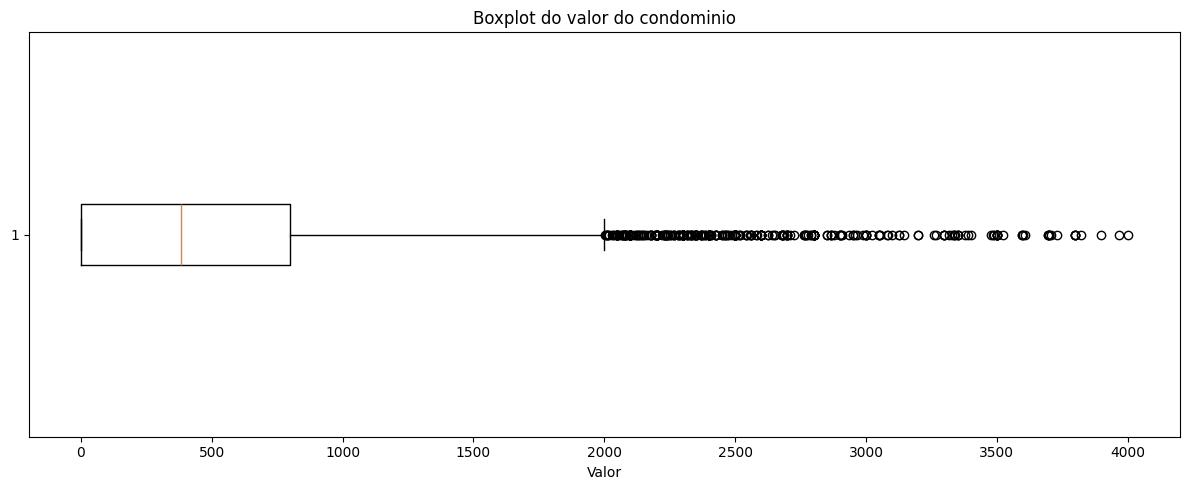

In [24]:
def gerarBoxplotHorizontal(dados):

    print("--- Resumo Estatístico ---")
    print(dados["valor_condominio"].describe())
    print("\n" + "=" * 30 + "\n")

    fig, ax = plt.subplots(figsize=(12, 5))
    
    ax.boxplot(dados['valor_condominio'], vert=False)
    ax.set_title('Boxplot do valor do condominio')
    ax.set_xlabel('Valor')
    
    plt.tight_layout()
    plt.show()

# Chamada da função com seus dados
gerarBoxplotHorizontal(dados_silver)

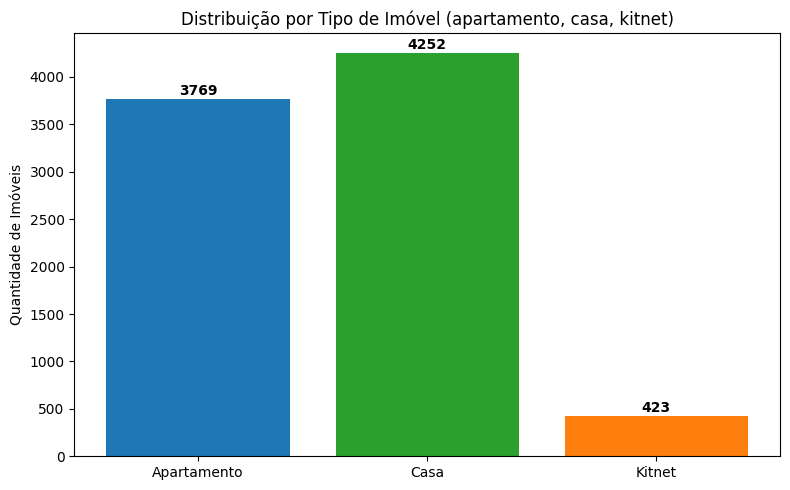

In [29]:
def graficoBarras(dados):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Contagem de registros por tipo de imóvel
    contagem = dados['tipo_imovel'].value_counts().sort_index()
    nomes_tipos = ['Apartamento', 'Casa', 'Kitnet'] if len(contagem) == 3 else [str(i) for i in contagem.index]
    cores = ['tab:blue', 'tab:green', 'tab:orange']

    ax.bar(nomes_tipos, contagem.values, color=cores[:len(contagem)])
    ax.set_ylabel('Quantidade de Imóveis')
    ax.set_title('Distribuição por Tipo de Imóvel (apartamento, casa, kitnet)')

    for i, v in enumerate(contagem.values):
        ax.text(i, v + 40, str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

graficoBarras(dados_silver)


Gerando visualizações gráficas...


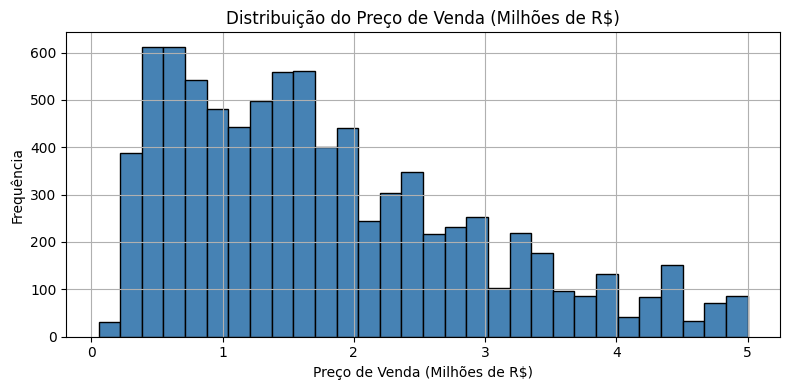

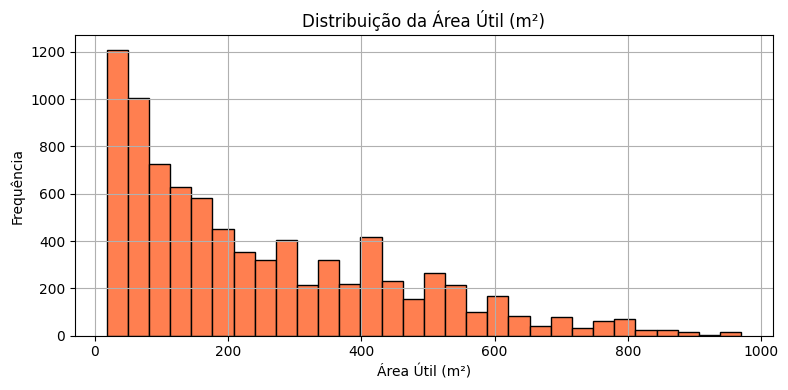

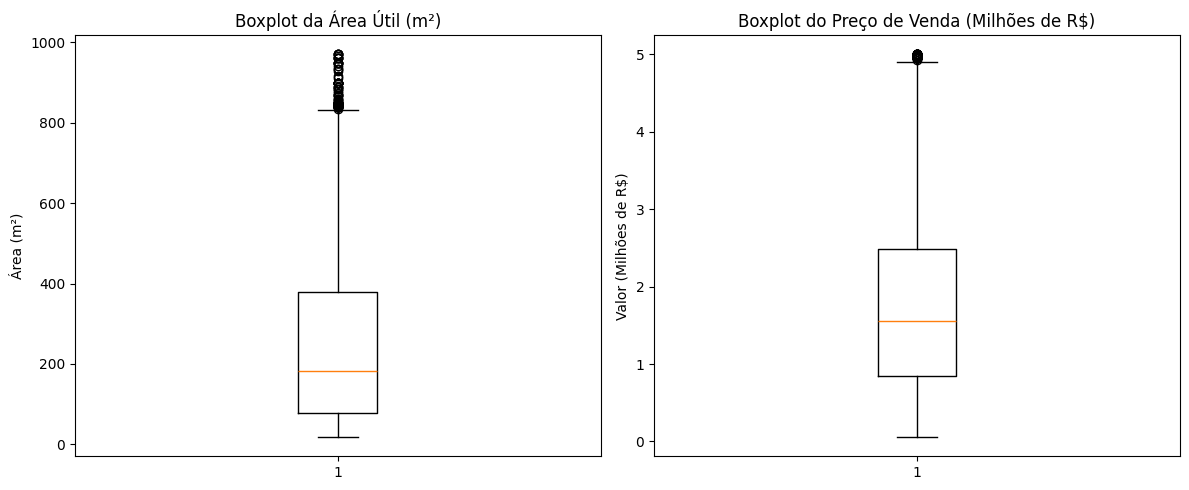

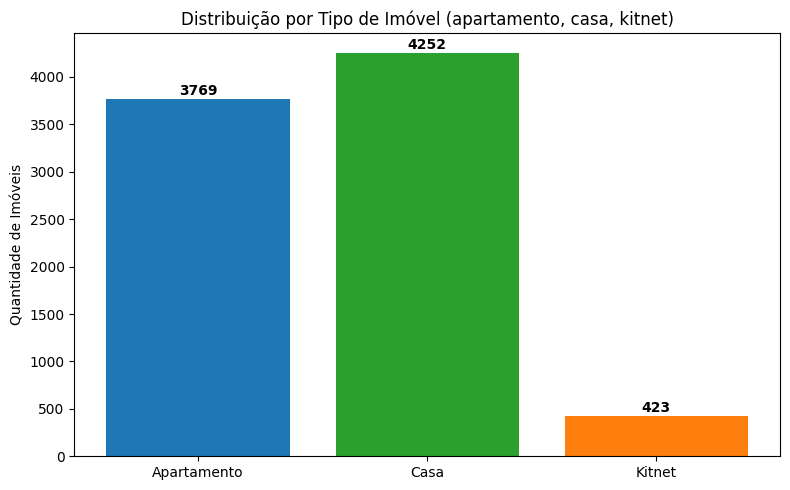

In [26]:
def visualizarDados(dados):
    print("\nGerando visualizações gráficas...")
    try:
        # Histograma do target (preco_venda em Milhões de R$)
        plt.figure(figsize=(8, 4))
        (dados['preco_venda'] / 1e6).hist(bins=30, edgecolor='black', color='steelblue')
        plt.title("Distribuição do Preço de Venda (Milhões de R$)")
        plt.xlabel("Preço de Venda (Milhões de R$)")
        plt.ylabel("Frequência")
        plt.tight_layout()
        plt.show()

        # Histograma da área útil
        plt.figure(figsize=(8, 4))
        dados['area_util'].hist(bins=30, edgecolor='black', color='coral')
        plt.title("Distribuição da Área Útil (m²)")
        plt.xlabel("Área Útil (m²)")
        plt.ylabel("Frequência")
        plt.tight_layout()
        plt.show()

        # Boxplots para visualização de dispersão
        gerarBoxplot(dados)

        # Gráfico de barras da nova coluna tipo_imovel
        graficoBarras(dados)
    except Exception as e:
        print(f"Aviso: Não foi possível renderizar gráficos na tela ({e}). O fluxo do pipeline continuará normalmente.")

visualizarDados(dados_silver)

### Análise de Correlação das Variáveis (Pearson)

A análise de correlação linear (coeficiente de Pearson, $r$) avalia a força e a direção da relação entre pares de variáveis contínuas:
- **$r = 1.0$**: Correlação linear positiva perfeita.
- **$r = 0.0$**: Ausência de correlação linear.
- **$r = -1.0$**: Correlação linear negativa perfeita.

Abaixo, geramos uma visualização dupla:
1. **Heatmap Completo**: Matriz de correlação entre todas as variáveis da base Silver (identifica também multicolinearidade entre variáveis preditoras).
2. **Ranking com o Target (`preco_venda`)**: Gráfico de barras ordenado para visualizar claramente quais atributos possuem maior relação direta com o preço do imóvel.

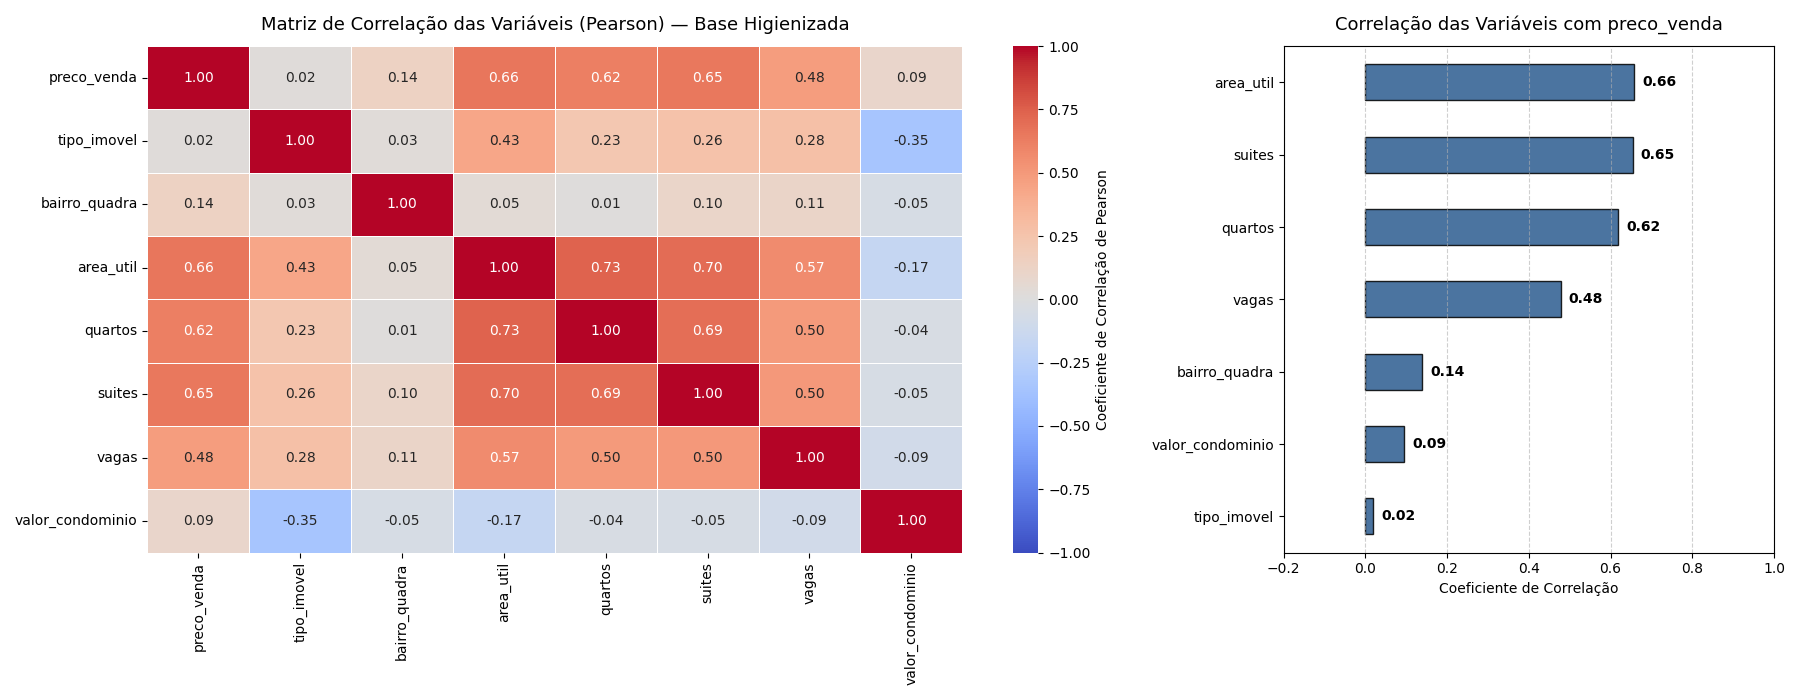

In [27]:
import seaborn as sns

def gerarGraficoCorrelacao(dados):
    """
    Gera visualização dupla de correlação:
    1. Heatmap da matriz de correlação completa (Pearson)
    2. Gráfico de barras com o ranking de correlação em relação a preco_venda
    """
    corr = dados.corr()
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios": [1.35, 0.65]})
    
    # 1. Heatmap Completo de Correlação
    sns.heatmap(
        corr, 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm", 
        center=0,
        vmin=-1, 
        vmax=1, 
        linewidths=0.5, 
        ax=axes[0],
        cbar_kws={"label": "Coeficiente de Correlação de Pearson"}
    )
    axes[0].set_title("Matriz de Correlação das Variáveis (Pearson)", fontsize=13, pad=12)
    
    # 2. Ranking de Correlação com o Preço de Venda (Target)
    corr_target = corr["preco_venda"].drop("preco_venda").sort_values(ascending=True)
    cores = ["#2b5c8f" if x >= 0 else "#d95f02" for x in corr_target]
    
    corr_target.plot(kind="barh", ax=axes[1], color=cores, edgecolor="black", alpha=0.85)
    axes[1].set_title("Correlação das Variáveis com preco_venda", fontsize=13, pad=12)
    axes[1].set_xlabel("Coeficiente de Correlação")
    axes[1].set_xlim(-0.2, 1.0)
    axes[1].grid(axis="x", linestyle="--", alpha=0.6)
    
    for i, v in enumerate(corr_target):
        axes[1].text(v + 0.02 if v >= 0 else v - 0.08, i, f"{v:.2f}", va="center", fontweight="bold")
        
    plt.tight_layout()
    plt.show()

gerarGraficoCorrelacao(dados_silver)


#### Interpretação das Correlações:
1. **Principais fatores de precificação (Correlação positiva com `preco_venda`)**:
   - `area_util` e `suites` possuem as maiores correlações lineares com o preço de venda, seguidas por `quartos` e `vagas`.
   - Isso reflete o comportamento do mercado: a metragem privativa e o número de suítes/vagas definem a faixa de valor e o padrão do imóvel.
2. **Multicolinearidade entre preditores**:
   - Há alta correlação mútua entre `area_util`, `quartos` e `suites` ($r > 0.70$). Imóveis maiores naturalmente possuem mais dormitórios.
   - Algoritmos lineares (Regressão Linear / Ridge) sofrem com multicolinearidade, enquanto modelos baseados em árvores (Random Forest / Gradient Boosting) lidam muito melhor com essas interações.
3. **Variáveis com correlação linear fraca ou não linear**:
   - `bairro_quadra`, `tipo_imovel` e `qtd_comodidades` apresentam baixa correlação linear direta com o preço global, pois seu efeito é segmentado e não-linear (ex: o bairro agrega valor dependendo do tipo do imóvel e da quadra específica, e não como uma progressão aritmética simples).